Лабораторна робота 1
"Зменшення розмірності даних"
Стецюк Максим КН-42

Мета роботи: Ознайомитися з основами зменшення розмірності даних (dimensionality reduction) на прикладі зображень рукописних цифр із набору MNIST. 
Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import matplotlib.patches as mpatches
import matplotlib

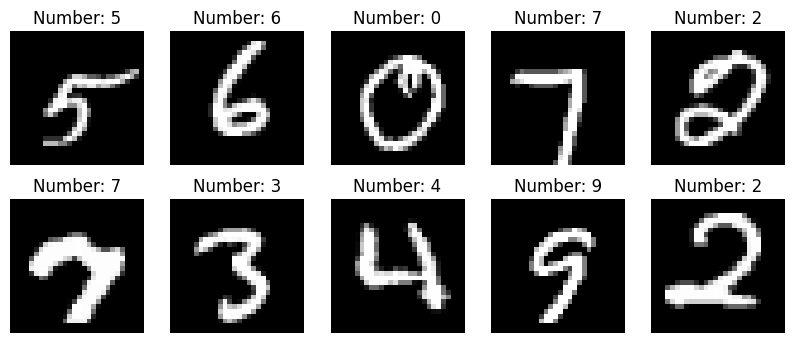

In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
plt.figure(figsize=(10, 4))
for i in range(10):
    idx = np.random.randint(0, X.shape[0])
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Number: {y[idx]}")
    plt.axis("off")

plt.show()

На цьому кроці, ми завантажили датасет MNIST, задали нашу матрицю та мітки для цифр. Тоді вибрали 10 випадкових цифр з датасету для демонстрації.

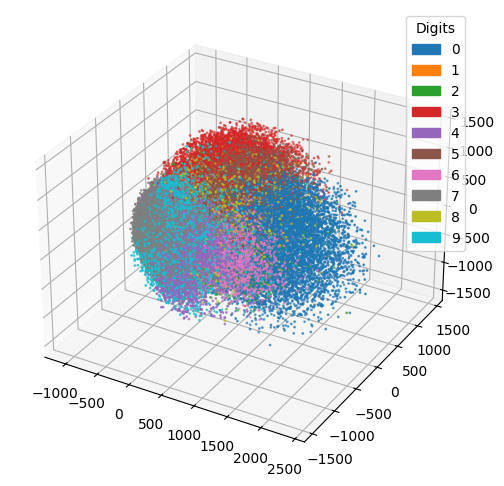

In [3]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=y.astype(int),
    cmap="tab10",
    s=1
)

cmap = matplotlib.colormaps["tab10"]
handles = []

for digit in range(10):
    handles.append(
        mpatches.Patch(color=cmap(digit), label=str(digit))
    )

ax.legend(handles=handles, title="Digits", loc="upper right")
plt.show()

У продемонстрованому тривимірному просторі бачимо, що PCA намагається розташувати подібні зображення ближче один до одного, тому бачимо утворені кластери. Через зменшення розмірності до 3, цифри перекривають одна одну, що свідчить про схожість характеристик класів

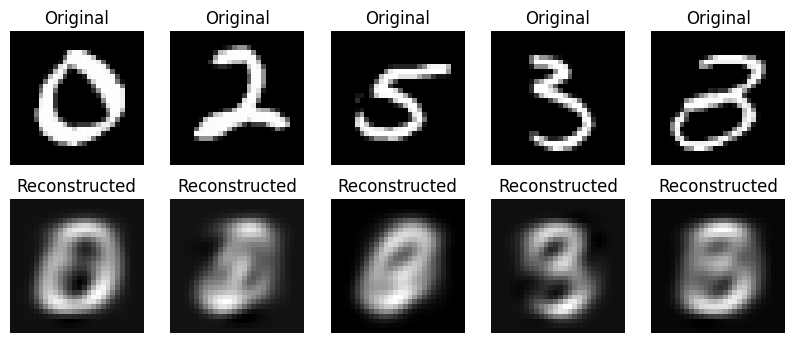

In [4]:
X_reconstructed = pca.inverse_transform(X_pca)
plt.figure(figsize=(10, 4))

for i in range(5):
    idx = np.random.randint(0, X.shape[0])

    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(X_reconstructed[idx].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

На цьому кроці виконуємо реконструкцію зображень після попереднього зменшення розмірності та порівнюємо з оригінальними зображеннями. Спостерігаємо, що відновленні зображення є розмитими та втратили схожість з оригіналом, що означає втрату частини інформації при зменшенні розмірності.

In [5]:
components = [1, 2, 5, 10, 20, 50, 100]
mse_values = []
explained = []

for k in components:
    pca_k = PCA(n_components=k)
    X_pca_k = pca_k.fit_transform(X)
    X_rec_k = pca_k.inverse_transform(X_pca_k)

    mse = mean_squared_error(X, X_rec_k)
    mse_values.append(mse)
    explained.append(np.sum(pca_k.explained_variance_ratio_))

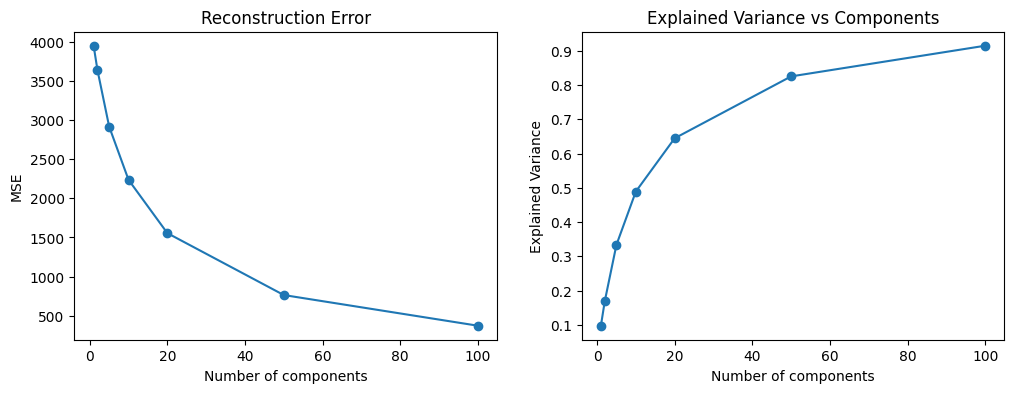

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(components, mse_values, marker="o")
plt.xlabel("Number of components")
plt.ylabel("MSE")
plt.title("Reconstruction Error")

plt.subplot(1, 2, 2)
plt.plot(components, explained, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Explained Variance")
plt.title("Explained Variance vs Components")

plt.show()

На першому графіку показано залежність помилки реконструкції від кількості компонент PCA, помітно, що зі збільшенням кількості компонент втрати стрімко зменшуються. На другому графіку бачимо залежність дисперсії від кількості компонент, тобто зі збільшенням кількості компонент зростає частка збереженої інформації.